In [1]:
# === Cell 1: Configuration ===

import numpy as np

# Protein family paths (relative to this notebook)
DATA_DIR = "../Large Scale/bmDCA"
PF1 = "PF00004"
PF2 = "PF00041"

PARAMS_FILE_1 = f"{DATA_DIR}/{PF1}/{PF1}_params.dat"
PARAMS_FILE_2 = f"{DATA_DIR}/{PF2}/{PF2}_params.dat"
NAT_ENERGIES_FILE_1 = f"{DATA_DIR}/{PF1}/{PF1}_naturalenergies.txt"
NAT_ENERGIES_FILE_2 = f"{DATA_DIR}/{PF2}/{PF2}_naturalenergies.txt"

# Overlap length in nucleotides
OVERLAP_LEN = 60

# Temperature grid
T1_RANGE = np.linspace(0.1, 1.5, 30)
T2_RANGE = np.linspace(0.1, 1.5, 30)

# Coarse sweep MC parameters
N_BURNIN = 100_000
N_SAMPLES = 500
THIN_INTERVAL = 200

# Detailed rerun MC parameters (for best-T histograms)
DETAILED_BURNIN = 200_000
DETAILED_SAMPLES = 2000
DETAILED_THIN = 500

# Random seed for reproducibility
SEED = 42

In [2]:
# === Cell 2: Data Loading & JIT Warmup ===

import sys
import os
import time

# Add parent directory so we can import overlappingGenes
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from overlappingGenes import (
    extract_params, load_natural_energies, initial_seq_no_stops,
    seq_str_to_int_array, mc_equilibrium_sampler
)

# Load DCA parameters
Js_1, hs_1 = extract_params(PARAMS_FILE_1)
Js_2, hs_2 = extract_params(PARAMS_FILE_2)

lenprot1 = len(hs_1) / 21
lenprot2 = len(hs_2) / 21
print(f"Protein 1 ({PF1}): {int(lenprot1)} AA, {int(3*lenprot1)} nt")
print(f"Protein 2 ({PF2}): {int(lenprot2)} AA, {int(3*lenprot2)} nt")
print(f"Overlap: {OVERLAP_LEN} nt")

# Load natural energies and compute stats
nat_energies_1 = np.array(load_natural_energies(NAT_ENERGIES_FILE_1))
nat_energies_2 = np.array(load_natural_energies(NAT_ENERGIES_FILE_2))
mean_1, std_1 = np.mean(nat_energies_1), np.std(nat_energies_1)
mean_2, std_2 = np.mean(nat_energies_2), np.std(nat_energies_2)
print(f"\nNatural energy stats:")
print(f"  {PF1}: mean={mean_1:.2f}, std={std_1:.2f} (n={len(nat_energies_1)})")
print(f"  {PF2}: mean={mean_2:.2f}, std={std_2:.2f} (n={len(nat_energies_2)})")

# Generate one initial sequence (fixed seed) shared across all grid points
np.random.seed(SEED)
init_seq_str = initial_seq_no_stops(lenprot1, lenprot2, OVERLAP_LEN, quiet=True)
init_seq_int = seq_str_to_int_array(init_seq_str)
print(f"\nInitial sequence length: {len(init_seq_int)} nt")

# JIT warmup (tiny run to compile all numba functions)
print("\nJIT warmup...")
t0 = time.time()
_ = mc_equilibrium_sampler(Js_1, hs_1, Js_2, hs_2, init_seq_int,
                           T1=1.0, T2=1.0,
                           n_burnin=10, n_samples=5, thin_interval=5)
print(f"JIT warmup done in {time.time() - t0:.1f}s")

Protein 1 (PF00004): 110 AA, 330 nt
Protein 2 (PF00041): 74 AA, 222 nt
Overlap: 60 nt

Natural energy stats:
  PF00004: mean=145.88, std=38.25 (n=213960)
  PF00041: mean=120.66, std=17.64 (n=701132)

Initial sequence length: 498 nt

JIT warmup...
JIT warmup done in 1.2s


In [3]:
# === Cell 3: Grid Sweep ===

from scipy.stats import ks_2samp, wasserstein_distance

n_T1 = len(T1_RANGE)
n_T2 = len(T2_RANGE)

# Metric grids
ks_grid = np.full((n_T2, n_T1), np.nan)
wass_grid = np.full((n_T2, n_T1), np.nan)
zscore_grid = np.full((n_T2, n_T1), np.nan)
accept_grid = np.full((n_T2, n_T1), np.nan)

total_points = n_T1 * n_T2
print(f"Grid sweep: {n_T1} x {n_T2} = {total_points} points")
print(f"MC per point: {N_BURNIN} burn-in + {N_SAMPLES} samples x {THIN_INTERVAL} thin = {N_BURNIN + N_SAMPLES * THIN_INTERVAL} steps")

t_start = time.time()

for i, T2 in enumerate(T2_RANGE):
    for j, T1 in enumerate(T1_RANGE):
        point_num = i * n_T1 + j + 1

        E1_samp, E2_samp, acc_rate = mc_equilibrium_sampler(
            Js_1, hs_1, Js_2, hs_2, init_seq_int,
            T1=T1, T2=T2,
            n_burnin=N_BURNIN, n_samples=N_SAMPLES, thin_interval=THIN_INTERVAL
        )

        # KS statistic (averaged over both proteins)
        ks1 = ks_2samp(nat_energies_1, E1_samp).statistic
        ks2 = ks_2samp(nat_energies_2, E2_samp).statistic
        ks_grid[i, j] = (ks1 + ks2) / 2

        # Wasserstein distance (averaged)
        w1 = wasserstein_distance(nat_energies_1, E1_samp)
        w2 = wasserstein_distance(nat_energies_2, E2_samp)
        wass_grid[i, j] = (w1 + w2) / 2

        # Mean z-score distance
        z1 = np.mean(np.abs((E1_samp - mean_1) / std_1))
        z2 = np.mean(np.abs((E2_samp - mean_2) / std_2))
        zscore_grid[i, j] = z1 + z2

        accept_grid[i, j] = acc_rate

        if point_num % 10 == 0 or point_num == total_points:
            elapsed = time.time() - t_start
            eta = elapsed / point_num * (total_points - point_num)
            print(f"  [{point_num}/{total_points}] T1={T1:.2f} T2={T2:.2f} "
                  f"acc={acc_rate:.3f} KS={ks_grid[i,j]:.3f} "
                  f"Wass={wass_grid[i,j]:.1f} Z={zscore_grid[i,j]:.2f} "
                  f"({elapsed:.0f}s elapsed, ~{eta:.0f}s remaining)")

print(f"\nGrid sweep done in {time.time() - t_start:.0f}s")

# Find best (T1, T2) per metric
def find_best(grid):
    idx = np.nanargmin(grid)
    i, j = np.unravel_index(idx, grid.shape)
    return T2_RANGE[i], T1_RANGE[j], grid[i, j]

best_ks_T2, best_ks_T1, best_ks_val = find_best(ks_grid)
best_wass_T2, best_wass_T1, best_wass_val = find_best(wass_grid)
best_z_T2, best_z_T1, best_z_val = find_best(zscore_grid)

print(f"\nBest temperatures:")
print(f"  KS:          T1={best_ks_T1:.3f}, T2={best_ks_T2:.3f} (KS={best_ks_val:.4f})")
print(f"  Wasserstein:  T1={best_wass_T1:.3f}, T2={best_wass_T2:.3f} (W={best_wass_val:.2f})")
print(f"  Z-score:      T1={best_z_T1:.3f}, T2={best_z_T2:.3f} (Z={best_z_val:.3f})")

Grid sweep: 30 x 30 = 900 points
MC per point: 100000 burn-in + 500 samples x 200 thin = 200000 steps
  [10/900] T1=0.53 T2=0.10 acc=0.302 KS=0.727 Wass=32.8 Z=2.56 (4s elapsed, ~347s remaining)
  [20/900] T1=1.02 T2=0.10 acc=0.410 KS=0.954 Wass=73.1 Z=5.20 (8s elapsed, ~345s remaining)
  [30/900] T1=1.50 T2=0.10 acc=0.469 KS=0.982 Wass=92.8 Z=6.29 (12s elapsed, ~345s remaining)
  [40/900] T1=0.53 T2=0.15 acc=0.292 KS=0.739 Wass=43.8 Z=4.00 (16s elapsed, ~341s remaining)
  [50/900] T1=1.02 T2=0.15 acc=0.418 KS=0.958 Wass=76.6 Z=5.52 (20s elapsed, ~335s remaining)
  [60/900] T1=1.50 T2=0.15 acc=0.479 KS=0.991 Wass=105.2 Z=7.54 (24s elapsed, ~330s remaining)
  [70/900] T1=0.53 T2=0.20 acc=0.292 KS=0.670 Wass=38.3 Z=3.49 (27s elapsed, ~325s remaining)
  [80/900] T1=1.02 T2=0.20 acc=0.419 KS=0.962 Wass=82.3 Z=6.34 (31s elapsed, ~321s remaining)
  [90/900] T1=1.50 T2=0.20 acc=0.483 KS=0.991 Wass=105.6 Z=7.36 (35s elapsed, ~317s remaining)
  [100/900] T1=0.53 T2=0.24 acc=0.286 KS=0.779 Wass=

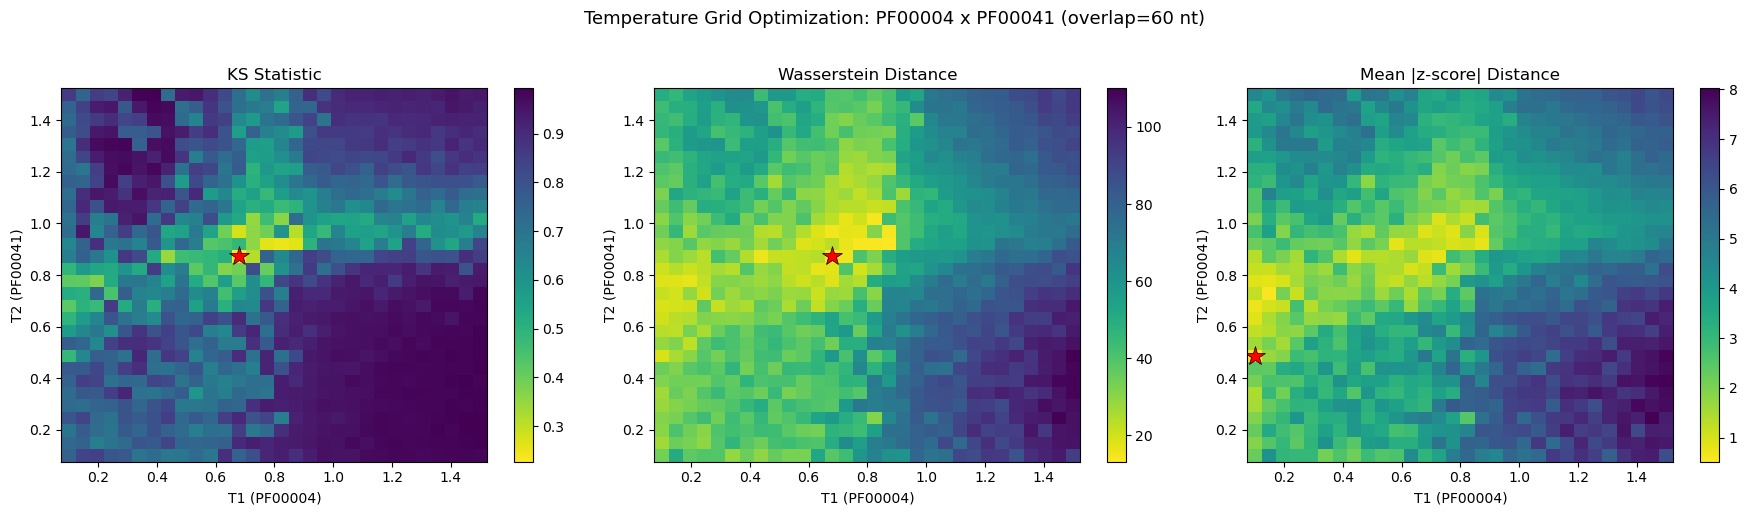

Saved temperature_heatmaps.png


In [4]:
# === Cell 4: Plot 1 — Three Heatmaps ===

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

grids = [ks_grid, wass_grid, zscore_grid]
titles = ["KS Statistic", "Wasserstein Distance", "Mean |z-score| Distance"]
bests = [
    (best_ks_T1, best_ks_T2),
    (best_wass_T1, best_wass_T2),
    (best_z_T1, best_z_T2),
]

for ax, grid, title, (bT1, bT2) in zip(axes, grids, titles, bests):
    pcm = ax.pcolormesh(T1_RANGE, T2_RANGE, grid, cmap="viridis_r", shading="auto")
    ax.plot(bT1, bT2, "r*", markersize=15, markeredgecolor="k", markeredgewidth=0.5)
    ax.set_xlabel(f"T1 ({PF1})")
    ax.set_ylabel(f"T2 ({PF2})")
    ax.set_title(title)
    fig.colorbar(pcm, ax=ax)

fig.suptitle(f"Temperature Grid Optimization: {PF1} x {PF2} (overlap={OVERLAP_LEN} nt)",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("temperature_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved temperature_heatmaps.png")

Running detailed MC at T1=0.679, T2=0.872
  200000 burn-in + 2000 samples x 500 thin
Done in 1s (acceptance=0.354)


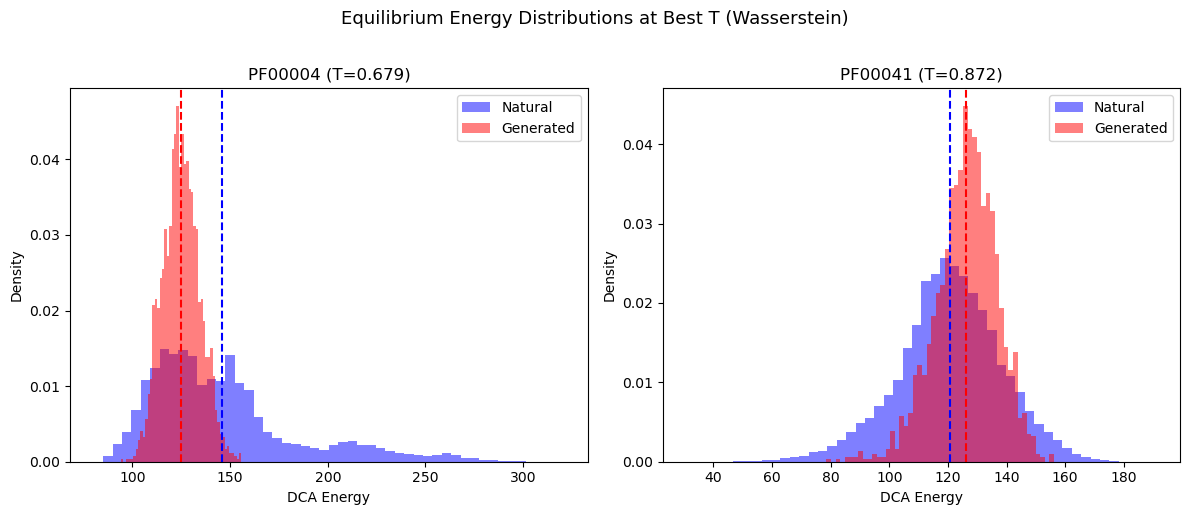

Saved energy_histograms.png


In [5]:
# === Cell 5: Plot 2 — Energy Histograms at Best T ===

# Use the Wasserstein-optimal T (distribution-matching metric)
T1_best = best_wass_T1
T2_best = best_wass_T2
print(f"Running detailed MC at T1={T1_best:.3f}, T2={T2_best:.3f}")
print(f"  {DETAILED_BURNIN} burn-in + {DETAILED_SAMPLES} samples x {DETAILED_THIN} thin")

t0 = time.time()
E1_det, E2_det, acc_det = mc_equilibrium_sampler(
    Js_1, hs_1, Js_2, hs_2, init_seq_int,
    T1=T1_best, T2=T2_best,
    n_burnin=DETAILED_BURNIN, n_samples=DETAILED_SAMPLES, thin_interval=DETAILED_THIN
)
print(f"Done in {time.time() - t0:.0f}s (acceptance={acc_det:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, nat_e, gen_e, pf, mu, sd in [
    (axes[0], nat_energies_1, E1_det, PF1, mean_1, std_1),
    (axes[1], nat_energies_2, E2_det, PF2, mean_2, std_2),
]:
    ax.hist(nat_e, bins=50, density=True, alpha=0.5, color="blue", label="Natural")
    ax.hist(gen_e, bins=50, density=True, alpha=0.5, color="red", label="Generated")
    ax.axvline(np.mean(nat_e), color="blue", linestyle="--", linewidth=1.5)
    ax.axvline(np.mean(gen_e), color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("DCA Energy")
    ax.set_ylabel("Density")
    ax.set_title(f"{pf} (T={T1_best if pf == PF1 else T2_best:.3f})")
    ax.legend()

fig.suptitle(f"Equilibrium Energy Distributions at Best T (Wasserstein)",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("energy_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved energy_histograms.png")

<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:56: SyntaxWarning: invalid escape sequence '\p'
C:\Users\orson\AppData\Local\Temp\ipykernel_24364\804367370.py:56: SyntaxWarning: invalid escape sequence '\p'
  f"Samples within $\pm 1\sigma$ (both): {within_1sigma:.1f}%\n"


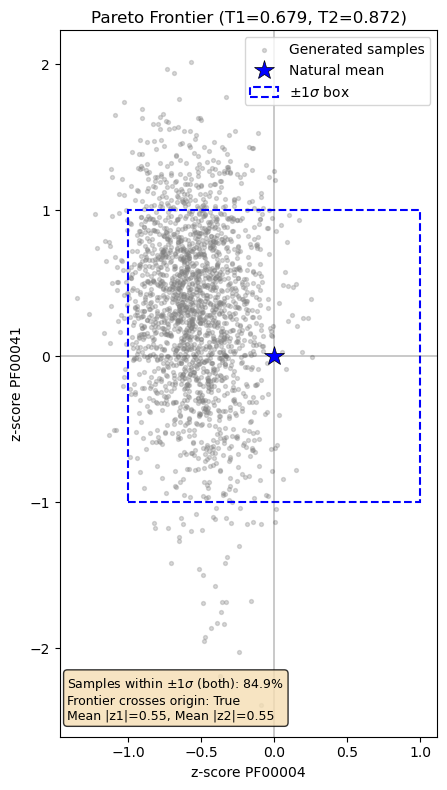

Saved pareto_frontier.png


In [7]:
# === Cell 6: Plot 3 — Pareto Frontier in Z-score Space ===

# Compute z-scores for the detailed run
z1_det = (E1_det - mean_1) / std_1
z2_det = (E2_det - mean_2) / std_2

# Find Pareto frontier: non-dominated points in (|z1|, |z2|) space
abs_z1 = np.abs(z1_det)
abs_z2 = np.abs(z2_det)

# Sort by |z1|
sort_idx = np.argsort(abs_z1)
pareto_mask = np.zeros(len(z1_det), dtype=bool)
min_z2_so_far = np.inf
for k in sort_idx:
    if abs_z2[k] < min_z2_so_far:
        pareto_mask[k] = True
        min_z2_so_far = abs_z2[k]

# Sort Pareto points for line plotting
pareto_z1 = z1_det[pareto_mask]
pareto_z2 = z2_det[pareto_mask]
pareto_abs_z1 = abs_z1[pareto_mask]
pareto_abs_z2 = abs_z2[pareto_mask]
pareto_order = np.argsort(pareto_abs_z1)

fig, ax = plt.subplots(figsize=(8, 8))

# Scatter all samples
ax.scatter(z1_det, z2_det, s=8, alpha=0.3, c="gray", label="Generated samples")



# Natural mean at origin
ax.plot(0, 0, "b*", markersize=15, markeredgecolor="k",
        markeredgewidth=0.5, zorder=5, label="Natural mean")

# +/- 1 sigma box
rect = plt.Rectangle((-1, -1), 2, 2, fill=False, edgecolor="blue",
                      linestyle="--", linewidth=1.5, label=r"$\pm 1\sigma$ box")
ax.add_patch(rect)

ax.set_xlabel(f"z-score {PF1}")
ax.set_ylabel(f"z-score {PF2}")
ax.set_title(f"Pareto Frontier (T1={T1_best:.3f}, T2={T2_best:.3f})")
ax.legend(loc="upper right")
ax.set_aspect("equal")
ax.axhline(0, color="k", linewidth=0.3)
ax.axvline(0, color="k", linewidth=0.3)

# Summary stats
within_1sigma = np.sum((np.abs(z1_det) <= 1) & (np.abs(z2_det) <= 1)) / len(z1_det) * 100
frontier_crosses = np.any((pareto_abs_z1 <= 0.1) & (pareto_abs_z2 <= 0.1))

stats_text = (
    f"Samples within $\pm 1\sigma$ (both): {within_1sigma:.1f}%\n"
    f"Frontier crosses origin: {frontier_crosses}\n"
    f"Mean |z1|={np.mean(abs_z1):.2f}, Mean |z2|={np.mean(abs_z2):.2f}"
)
ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment="bottom", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

fig.tight_layout()
fig.savefig("pareto_frontier.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved pareto_frontier.png")